Niklas Fritz, 421248

## Task 1: Analysing Pre-trained Word Embeddings (6 Points)

In [3]:
from tutorial2_task1 import load_glove_model

model = load_glove_model("glove.6B.50d.txt")
vocab = list(model.keys())

print(f"{len(vocab)} words found with {len(model['the'])} vector size!")

400000 words found with 50 vector size!


### Finding Distance Between Words

Let's explore whether the pre-trained word embeddings accurately reflect the intuitive similarity between words. For instance, we would expect the word "dog" to be more similar to "cat" (as both are pet animals) than to a word like "ball." We can verify this assumption using the word embeddings.

In [4]:
from tutorial2_task1 import cosine_distance

d_dog_cat = cosine_distance(model["dog"], model["cat"])
d_dog_ball = cosine_distance(model["dog"], model["ball"])

print(f"Distance between dog and cat: {d_dog_cat}")
print(f"Distance between dog and bear: {d_dog_ball}")

Distance between dog and cat: 0.07819956541061401
Distance between dog and bear: 0.5058270692825317


Having established the ability to measure the distance between two words using their word embeddings, we can now extend this approach to compare a specific word against all words in our pre-trained model. For instance, which words are most similar to "awesome" in this context? Let's find out:

In [5]:
from tutorial2_task1 import most_similar
from tutorial2_task1 import cosine_distance, euclidean_distance

similar_words_cosine = most_similar(model["awesome"], model, cosine_distance)
similar_words_euclidean = most_similar(model["awesome"], model, euclidean_distance)

print("Cosine distance:")
print(similar_words_cosine)

print("Euclidean distance:")
print(similar_words_euclidean)

Cosine distance:
[('awesome', np.float32(-1.1920929e-07)), ('unbelievable', np.float32(0.13613915)), ('amazing', np.float32(0.13793355)), ('incredible', np.float32(0.15291148)), ('fantastic', np.float32(0.1940301)), ('marvelous', np.float32(0.21001011)), ('terrific', np.float32(0.21978825)), ('phenomenal', np.float32(0.2554978)), ('truly', np.float32(0.25664538)), ('luck', np.float32(0.2759173))]
Euclidean distance:
[('awesome', np.float32(0.0)), ('amazing', np.float32(2.2457943)), ('unbelievable', np.float32(2.3429704)), ('incredible', np.float32(2.348345)), ('marvelous', np.float32(2.417427)), ('terrific', np.float32(2.545364)), ('fantastic', np.float32(2.595255)), ('phenomenal', np.float32(2.8482318)), ('marvellous', np.float32(2.8635528)), ('luck', np.float32(2.9113293))]


### Compare Similarity Between Groups of Words

In [6]:
common_words = [
    # colors
    "red", "orange", "yellow", "green", "blue", "purple",
    "pink", "brown", "black", "grey", "white", "violet", 
    # months
    "january", "february", "march", "april", "may", "june", 
    "july", "august", "september", "october", "november", "december",
]

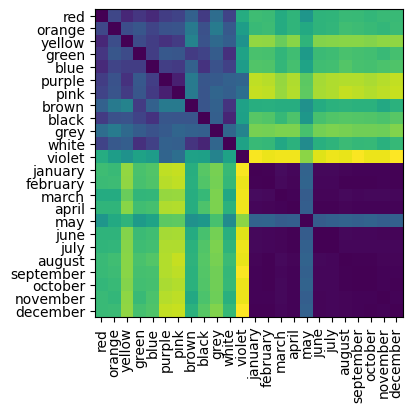

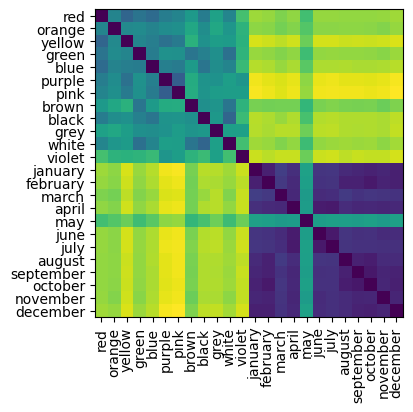

In [7]:
from tutorial2_task1 import show_similarities

show_similarities(common_words, model, cosine_distance)
show_similarities(common_words, model, euclidean_distance)

Do the word embeddings agree with you assumption of relatedness between words?

Your answer: 

Yes they do. One observes, that all months are highly related. The colors show nicely that colors which are related (such as black and white) show stronger similarity. The moth may is extraordinary, because "may" could also be interpretated as the verb "may".

### Vector Arithmetic for Analogy Solving

What happens if we subtract 'man' from 'king'? This is like asking the model to take the concept of 'king', and remove 'maleness' from it. What you're left with (in theory) is the concept of royalty or a ruler without the gender association. Then, by adding the vector for 'woman', you're essentially asking the model to provide a word that is similar to a 'king', but with a feminine aspect.

That´s really cool to see :)

In [8]:
import numpy as np
vec = model["king"] - model["man"] + model["woman"]
similar_words = most_similar(vec, model, euclidean_distance, ignore_vec=np.array([model["king"]]))

print(similar_words)
print(most_similar(model["king"], model, euclidean_distance))

[('queen', np.float32(2.8391209)), ('prince', np.float32(3.661004)), ('elizabeth', np.float32(3.715252)), ('daughter', np.float32(3.8317876)), ('widow', np.float32(3.8493776)), ('throne', np.float32(3.8837435)), ('monarch', np.float32(3.8925035)), ('cousin', np.float32(3.9533188)), ('eldest', np.float32(3.962192)), ('princess', np.float32(3.9624627))]
[('king', np.float32(0.0)), ('prince', np.float32(3.1179736)), ('queen', np.float32(3.477756)), ('uncle', np.float32(3.5069308)), ('ii', np.float32(3.5766704)), ('grandson', np.float32(3.691133)), ('brother', np.float32(3.6961105)), ('kingdom', np.float32(3.726456)), ('son', np.float32(3.7550519)), ('nephew', np.float32(3.7816255))]


More analogies:

In [11]:
from tutorial2_task1 import analogies


print(analogies("man", "king", "woman", model))
print(analogies("brazil", "pele", "argentina", model))
print(analogies("america", "washington", "germany", model))
print(analogies("boy", "father", "girl", model))
print(analogies("tennis", "ball", "rugby", model))
print(analogies("tennis", "racket", "hockey", model))
print(analogies("france", "paris", "germany", model))  
print(analogies("italy", "rome", "spain", model))     
print(analogies("run", "running", "swim", model)) 
print(analogies("walk", "walking", "crawl", model))
print(analogies("germany", "euro", "usa", model))       
print(analogies("january", "june", "february", model))


queen
maradona
berlin
mother
giggs
pucks
berlin
juan
swimming
crawling
nz
april


## Task 2 (Computing Word Embeddings - Word2Vec (12 points)

### Preparing Training Set

In [1]:
from tutorial2_task2 import tokenize

tokens = tokenize("tutorial2.txt")
print(tokens)
print(tokens[0:10])

['the', 'stand', 'up', 'was', 'by', 'far', 'the', 'best', 'one', 'the', 'comedy', 'special', 'was', 'horrible', 'this', 'movie', 'also', 'has', 'a', 'very', 'good', 'ending', 'the', 'ending', 'was', 'sorry', 'as', 'i', 'just', 'did', 'not', 'care', 'for', 'the', 'characters', 'the', 'plot', 'is', 'tight', 'and', 'the', 'acting', 'is', 'flawless', 'the', 'plot', 'is', 'predictable', 'and', 'the', 'movie', 'is', 'long', 'good', 'historical', 'drama', 'which', 'is', 'very', 'educational', 'and', 'entertaining', 'it', 'was', 'entirely', 'over', 'dramatic', 'and', 'boring', 'the', 'romance', 'of', 'the', 'movie', 'is', 'good', 'and', 'nicely', 'presented', 'it', 'was', 'the', 'most', 'terrible', 'romance', 'movie', 'i', 'had', 'ever', 'watched', 'movie', 'has', 'a', 'unique', 'science', 'fiction', 'element', 'which', 'makes', 'it', 'hilarious', 'the', 'old', 'science', 'fiction', 'trope', 'is', 'overused', 'and', 'stale', 'this', 'movie', 'is', 'rich', 'with', 'action', 'and', 'gore', 'to',

In [2]:
from tutorial2_task2 import generate_training_data

context_window_size = 1

center_words, context_words = generate_training_data(tokens, context_window_size=context_window_size)

print(center_words, context_words)

['stand', 'up', 'was', 'by', 'far', 'the', 'best', 'one', 'the', 'comedy', 'special', 'was', 'horrible', 'this', 'movie', 'also', 'has', 'a', 'very', 'good', 'ending', 'the', 'ending', 'was', 'sorry', 'as', 'i', 'just', 'did', 'not', 'care', 'for', 'the', 'characters', 'the', 'plot', 'is', 'tight', 'and', 'the', 'acting', 'is', 'flawless', 'the', 'plot', 'is', 'predictable', 'and', 'the', 'movie', 'is', 'long', 'good', 'historical', 'drama', 'which', 'is', 'very', 'educational', 'and', 'entertaining', 'it', 'was', 'entirely', 'over', 'dramatic', 'and', 'boring', 'the', 'romance', 'of', 'the', 'movie', 'is', 'good', 'and', 'nicely', 'presented', 'it', 'was', 'the', 'most', 'terrible', 'romance', 'movie', 'i', 'had', 'ever', 'watched', 'movie', 'has', 'a', 'unique', 'science', 'fiction', 'element', 'which', 'makes', 'it', 'hilarious', 'the', 'old', 'science', 'fiction', 'trope', 'is', 'overused', 'and', 'stale', 'this', 'movie', 'is', 'rich', 'with', 'action', 'and', 'gore', 'to', 'make'

#### Train the following CBOW and SkipGram models by completing their 'forward' functions. Use appropriate activation functions wherever necessary.

In [3]:
import torch
import torch.optim as optim

from tutorial2_task2 import generate_mappings

vocabulary, word2id, id2word = generate_mappings(tokens)

# defining hyperparameters
embedding_dim = 50
num_epochs = 200
context_size = 2 * context_window_size


##### Training CBOW

In [4]:
from tutorial2_task2 import CBOW, train_word2vec

cbow_inputs = torch.tensor([[word2id[w] for w in row] for row in context_words])
cbow_targets = torch.tensor([[word2id[w]] for w in center_words])

cbow_model = CBOW(len(vocabulary), context_size, embedding_dim)
cbow_loss = train_word2vec(cbow_model, cbow_inputs, cbow_targets, num_epochs)
print(cbow_loss)

[1115.8526973724365, 997.1248720884323, 887.8934723138809, 786.4397285878658, 689.3981409370899, 593.7326610609889, 500.2918260022998, 410.49639470130205, 328.14127327501774, 256.5096529237926, 197.66900769993663, 152.51517577283084, 120.2289033420384, 98.21728287450969, 83.43583517894149, 73.45530745945871, 66.47676071897149, 61.32284370902926, 57.41711924504489, 54.34430279675871, 51.82234745146707, 49.77163068763912, 47.98485793499276, 46.44366737594828, 45.10624950705096, 43.88796395622194, 42.838010598672554, 41.86665617628023, 40.97891133255325, 40.146199993090704, 39.45341194816865, 38.794922028901055, 38.10092395520769, 37.456351863220334, 36.87711456883699, 36.36773805040866, 35.88393244869076, 35.4156591584906, 34.981098613119684, 34.543882119236514, 34.15587790473364, 33.757930243504234, 33.42493022792041, 33.0848883157596, 32.76101915969048, 32.45940085442271, 32.16067164344713, 31.881324536167085, 31.62541387428064, 31.343128110514954, 31.101991153438576, 30.86337806761730

##### Training SkipGram

In [5]:
from tutorial2_task2 import SkipGram, train_word2vec

skipgram_inputs = cbow_targets
skipgram_targets = cbow_inputs

skipgram_model = SkipGram(len(vocabulary), context_size, embedding_dim)
skipgram_loss = train_word2vec(skipgram_model, skipgram_inputs, skipgram_targets, num_epochs=num_epochs)

##### Comparing Training Performance

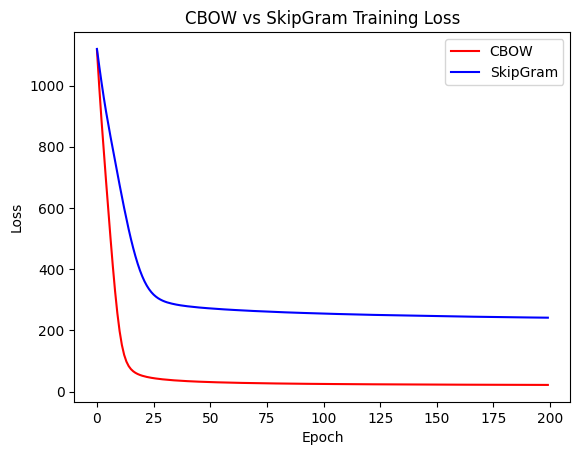

In [6]:
from tutorial2_task2 import plot_loss

plot_loss(
    'CBOW vs SkipGram Training Loss', 
    [
        (cbow_loss, "CBOW", "r"), 
        (skipgram_loss, "SkipGram", "b"),
    ]
)

#### Retrain Using a Larger Context Size

In [16]:
# TODO: choose one and comment the other
model_cls = CBOW
#model_cls = SkipGram

context_window_size = 2
context_size = 2 * context_window_size

center_words, context_words = generate_training_data(tokens, context_window_size=context_window_size)

context_words_idx = torch.tensor([[word2id[w] for w in row] for row in context_words])
center_words_idx = torch.tensor([[word2id[w]] for w in center_words])

model = model_cls(vocab_size=len(vocabulary), context_size=context_size, embedding_dim=embedding_dim)

if isinstance(model, CBOW):
    inputs = context_words_idx
    targets = center_words_idx

if isinstance(model, SkipGram):
    inputs = center_words_idx
    targets = context_words_idx
    
loss = train_word2vec(model, inputs, targets, num_epochs=num_epochs)

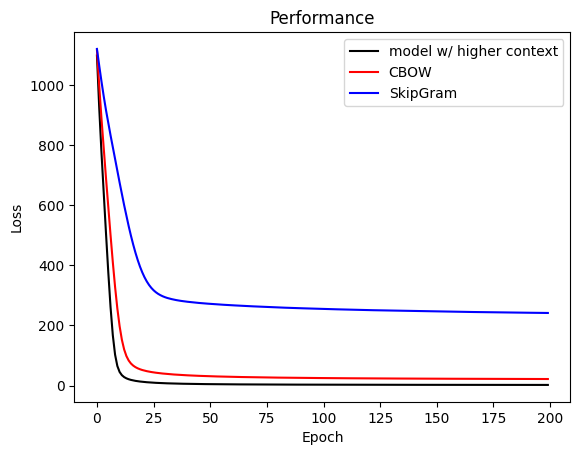

In [17]:
from tutorial2_task2 import plot_loss

plot_loss(
    "Performance", 
    [
        (loss, "model w/ higher context", "k"), 
        (cbow_loss, "CBOW", "r"), 
        (skipgram_loss, "SkipGram", "b"),
    ]
)

Does the context window affect the performance of the model? Explain in not more than 50 words.

Your response: 
### Skipgram
Loss seems to be higher in earlier training process. This is because the task is much more complex if there is greater context size (we want to predict cpntext words!). Words more far away may not be strongly related to words. Frthermore there are more terms in loss teerm because there are more words to predict. With more epochs of leaarning, the loss gets smaller.

### CBOW
In CBOW we have just one word to predict, the center word out of window size of context words. We get more context information by a larger context window. The loss decreaes faster and we get better prediction in conatrast to smaller window size.

## Making Predictions

In [12]:
context_words = ["most", "romance"]

# Convert context words to their respective indices
context_indices = torch.tensor([word2id[word] for word in context_words])

# Get the model output
log_probs = cbow_model(context_indices)

# Find the word index with the highest probability
max_prob_idx = torch.argmax(log_probs).item()

# Find the word corresponding to the predicted index
predicted_word = id2word[max_prob_idx]

print(f"The predicted center word is '{predicted_word}'")

The predicted center word is 'terrible'


Now it's your turn to apply a similar approach with the SkipGram model. Complete the code below to predict the context words surrounding a given center word using the SkipGram model.

In [15]:
center_word = "movie"

# Convert the center word to its respective index
center_indices = torch.tensor([word2id[center_word]])

# Get the model output
log_probs = skipgram_model(center_indices)

# Find the word indices with the highest probability
max_prob_idx = [torch.argmax(probs).item() for probs in log_probs]

# Find the word corresponding to the predicted index
predicted_words = [id2word[id] for id in max_prob_idx]

print(f"The predicted context words are {predicted_words}")

tensor([[ -8.7411, -10.9961,  -7.8504,  -6.5458,  -9.5164,  -8.7065,  -9.8093,
          -9.3403,  -9.0100,  -9.5037,  -9.5628,  -9.0774,  -9.8352,  -8.7819,
          -8.9479,  -8.7889,  -6.4231,  -7.7802, -10.5994,  -9.0674,  -8.9478,
         -11.0051,  -8.6961, -10.1799, -10.3687,  -8.8443, -10.1110, -10.3866,
          -8.9170,  -9.2930, -10.2344,  -8.9797,  -8.0181, -11.2274,  -6.9481,
          -7.8784,  -7.4843, -10.4081, -10.0326,  -9.7731,  -7.9900,  -9.0072,
          -9.4385,  -9.3947,  -8.8681,  -8.0507,  -7.7839,  -8.4665,  -9.6157,
         -10.6226,  -8.6656,  -8.6535, -11.1490, -10.7388,  -8.3214,  -8.4286,
          -7.8008,  -8.0615,  -1.3299, -10.9448, -10.5766,  -0.8094,  -9.6379,
          -9.6153,  -8.9849,  -8.0365,  -9.6152,  -9.1681,  -9.3853,  -9.2013,
          -9.7914,  -9.7887,  -7.5582,  -7.9835,  -2.0397,  -9.1450,  -8.0340,
          -9.8420,  -7.3370,  -8.6131,  -9.7847,  -8.7058,  -7.7780,  -9.0221,
          -9.2485,  -9.3863,  -7.5410,  -8.9256,  -8

### Task 3: Implementing RNN-LSTM classifier (6 points)

Create a moview review dataset having all the positive and negative reviews from file 'tutorial2.txt':

In [1]:
from tutorial2_task3 import load_training_data

words, targets = load_training_data("tutorial2.txt")

print(words[0], targets[0])

['the', 'stand', 'up', 'was', 'by', 'far', 'the', 'best', 'one'] tensor(0)


Encode and pad the input words.

In [7]:
from tutorial2_task1 import load_glove_model
from tutorial2_task3 import generate_mappings, encode_and_pad

embeddings = load_glove_model("glove.6B.50d.txt")
vocabulary, word2id, id2word = generate_mappings(embeddings)
"""
    Example:
    >>> embeddings = {"the": np.array([1.0, 2.0]), "a": np.array([3.0, 4.0])}
    >>> vocabulary, word2id, id2word = generate_mappings(embeddings)
    >>> print(vocabulary) # Prints ['<unk>', 'the', 'a']
    >>> print(word2id)   # Prints {'<unk>': 0, 'the': 1, 'a': 2}
    >>> print(id2word)   # Prints {0: '<unk>', 1: 'the', 2: 'a'}
"""
features = encode_and_pad(words, word2id, 20)

print(features[0])

'\n    Example:\n    >>> embeddings = {"the": np.array([1.0, 2.0]), "a": np.array([3.0, 4.0])}\n    >>> vocabulary, word2id, id2word = generate_mappings(embeddings)\n    >>> print(vocabulary) # Prints [\'<unk>\', \'the\', \'a\']\n    >>> print(word2id)   # Prints {\'<unk>\': 0, \'the\': 1, \'a\': 2}\n    >>> print(id2word)   # Prints {0: \'<unk>\', 1: \'the\', 2: \'a\'}\n'

Split the dataset into train (80%) and test (20%):

In [3]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    # TODO
    words,                 # Eingabedaten
    targets,               # Zielwerte
    test_size=0.2,         # 20% Testdaten 
    random_state=42,       # für Reproduzierbarkeit
    shuffle=True           # durchmischen 
)
x_train_ids = [[word2id.get(w, 0) for w in line] for line in x_train] 
x_test_ids = [[word2id.get(w, 0) for w in line] for line in x_test]

Train a simple RNN-LSTM classifier:

In [4]:
from tutorial2_task3 import train
import torch

embeddings_tensor = torch.tensor(list(embeddings.values()))

losses, clf = train(x_train_ids, y_train, num_epochs=50, embeddings=embeddings_tensor)



C:\Users\User\AppData\Local\Temp\ipykernel_37704\666038402.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  embeddings_tensor = torch.tensor(list(embeddings.values()))


Epoch 1/50, Loss: 26.4136
Epoch 2/50, Loss: 15.0249
Epoch 3/50, Loss: 13.6996
Epoch 4/50, Loss: 13.8325
Epoch 5/50, Loss: 13.8444
Epoch 6/50, Loss: 13.4913
Epoch 7/50, Loss: 9.2619
Epoch 8/50, Loss: 2.9245
Epoch 9/50, Loss: 1.4797
Epoch 10/50, Loss: 0.8876
Epoch 11/50, Loss: 0.2901
Epoch 12/50, Loss: 0.1349
Epoch 13/50, Loss: 0.0305
Epoch 14/50, Loss: 0.0227
Epoch 15/50, Loss: 0.0189
Epoch 16/50, Loss: 0.0163
Epoch 17/50, Loss: 0.0145
Epoch 18/50, Loss: 0.0130
Epoch 19/50, Loss: 0.0119
Epoch 20/50, Loss: 0.0110
Epoch 21/50, Loss: 0.0101
Epoch 22/50, Loss: 0.0093
Epoch 23/50, Loss: 0.0084
Epoch 24/50, Loss: 0.0078
Epoch 25/50, Loss: 0.0074
Epoch 26/50, Loss: 0.0070
Epoch 27/50, Loss: 0.0066
Epoch 28/50, Loss: 0.0062
Epoch 29/50, Loss: 0.0059
Epoch 30/50, Loss: 0.0056
Epoch 31/50, Loss: 0.0054
Epoch 32/50, Loss: 0.0052
Epoch 33/50, Loss: 0.0049
Epoch 34/50, Loss: 0.0047
Epoch 35/50, Loss: 0.0045
Epoch 36/50, Loss: 0.0043
Epoch 37/50, Loss: 0.0042
Epoch 38/50, Loss: 0.0040
Epoch 39/50, Lo

Until now I use not the GloVe enbeddings, they are learned in the LSTM. As the loss decreases I think it is sufficient.

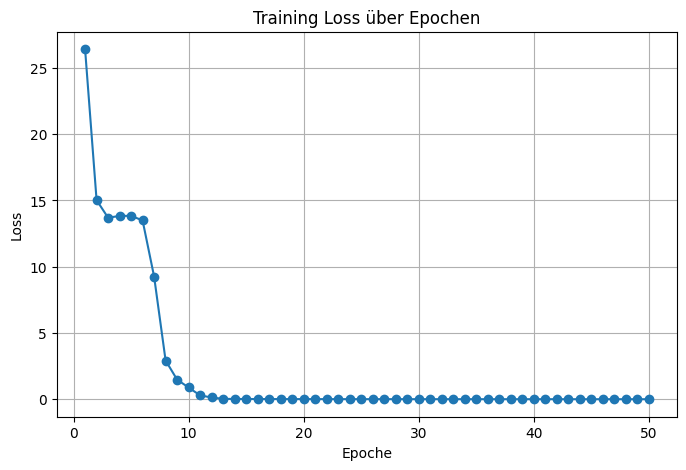

In [5]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.title("Training Loss über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [6]:
# clf habe ich über train mitgegeben
correct = 0
total = 0

with torch.no_grad():  # keine Gradienten nötig
    for x, y in zip(x_test_ids, y_test):
        if len(x) == 0:
            continue
        x_tensor = torch.tensor(x, dtype=torch.long)
        output = clf(x_tensor)
        predicted = 1 if output.item() >= 0.5 else 0  # Schwelle bei 0.5
        total += 1
        correct += (predicted == y.item())

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Accuracy: 60.00%


### Task 4 Bert Embedding


In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
#from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import DistanceMetric
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. Load the resume dataset (resumes_train.csv)
# TODO: Read the CSV file and store it in a DataFrame named 'df_resume'
# HINT: Use pd.read_csv() to load the file

# Display the first few rows of the dataset
# TODO: Display the head of the dataframe to inspect the structure
# HINT: Use df_resume.head()
df_resume = pd.read_csv("resumes_train.csv")

print(df_resume.head())


                                              resume            role
0  ### John Doe\n\n---\n\n#### Summary\nDetail-or...  Data Scientist
1  Creating a resume for a Data Scientist based o...  Data Scientist
2  Creating a resume for a Data Scientist...\n\n-...  Data Scientist
3  Creating a resume for a Data Scientist based o...  Data Scientist
4  ## John Doe\n\n---\n\n### Summary:\nData Scien...  Data Scientist
Index(['resume', 'role'], dtype='object')


I don´t see where the next code chunk is needed. If I understand correctly, we get the embeddings here by the SentenceTransformer model.

In [8]:
#from tutorial2_task3 import train
#import torch

#embeddings_tensor = torch.tensor(list(embeddings.values()))

#losses, clf = train(x_train_ids, y_train, num_epochs=50, embeddings=embeddings_tensor)



C:\Users\User\AppData\Local\Temp\ipykernel_972\666038402.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  embeddings_tensor = torch.tensor(list(embeddings.values()))


NameError: name 'x_train_ids' is not defined

In [ ]:
# 2. Encode the resumes using a pre-trained model
# TODO: Initialize the SentenceTransformer model (use 'all-MiniLM-L6-v2') and encode the 'resume' column
# HINT: Use model.encode() to encode the resumes and store them in 'embedding_arr'

# TODO: Print the shape of 'embedding_arr' to check the dimensionality of the embeddings

model = SentenceTransformer('all-MiniLM-L6-v2') #this is a predefined model constructing embeddngs for sentences

embeddings = model.encode(df_resume['resume'].tolist(), show_progress_bar=True)

print("Shape of embedding array:", np.array(embeddings).shape)

In [ ]:

# 3. Apply PCA to reduce dimensionality
# TODO: Apply PCA to reduce the embedding dimension to 2 components
# HINT: Use PCA(n_components=2) and fit it to 'embedding_arr'

# TODO: Print the explained variance ratio of the first two components
# HINT: Use pca.explained_variance_ratio_

from sklearn.decomposition import PCA
import numpy as np

# PCA-modell mit 2 Komponenten erstellen
pca = PCA(n_components=2)

# PCA auf die Embeddings anwenden
embedding_2d = pca.fit_transform(np.array(embeddings))

# Erklärte Varianz der ersten beiden Komponenten ausgeben

print("Explained variance ratio (first 2 components):", pca.explained_variance_ratio_)




# 4. Visualize the resumes using PCA components
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 16})
plt.grid()

c = 0
cmap = mpl.colormaps['jet']

# TODO: Loop through each unique role in df_resume['role'], extract the corresponding embeddings, and plot them
# HINT: Use plt.scatter() to plot the PCA-transformed embeddings for each role

unique_roles = df_resume['role'].unique()

for i, role in enumerate(unique_roles):
    # Embeddings auswählen, die zu dieser Rolle gehören
    idx = df_resume['role'] == role
    role_pca = embedding_2d[idx]

    # Farbe auswählen
    color = cmap(i / len(unique_roles))

    # Scatter-Plot für diese Rolle
    plt.scatter(role_pca[:, 0], role_pca[:, 1], 
                label=role, 
                color=color)
plt.legend(bbox_to_anchor=(1.05, 0.9))
plt.xticks(rotation=45)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


In [ ]:

# 5. Define a job query
# TODO: Define a query as a string. This query represents the job you are searching for
# EXAMPLE: "Data Engineer with Apache Airflow experience"
# 5. Job-Query definieren

job_query = "Data Engineer with experience in Python and SQL"


# 6. Encode the job query using the same model
# TODO: Encode the job query using the SentenceTransformer model and store the result in 'query_embedding'
query_embedding = model.encode(job_query) # get embedding for the job query




NameError: name 'model' is not defined

In [ ]:
# 7. Compute the distances between the query and resumes
# TODO: Initialize the distance metric (Euclidean distance) and compute the distances between the query and each resume
# HINT: Use DistanceMetric.get_metric() and pairwise() to compute the distances

# TODO: Sort the resumes based on the distances and store the indices of the sorted array in 'idist_arr_sorted'
# HINT: Use np.argsort()
from sklearn.metrics import DistanceMetric

dist = DistanceMetric.get_metric('euclidean')

# query_embedding muss 2D sein für pairwise: reshape(1, -1)

distances = dist.pairwise(np.array(embeddings), query_embedding.reshape(1, -1))

idist_arr_sorted = np.argsort(distances[:, 0])

# 8. Display the top 10 most relevant roles
# TODO: Print the top 10 most relevant roles based on the sorted distances
# HINT: Use df_resume['role'].iloc[] with the sorted indices

top_10_indices = idist_arr_sorted[:10] # ersten 10 Indizes
top_10_roles = df_resume['role'].iloc[top_10_indices]

print("Top 10 most relevant roles for the query:")
for i, role in enumerate(top_10_roles, 1):
    print(f"{i}. {role}")

# 9. Display the most relevant resume
# TODO: Print the resume text that is the closest match to the query
# HINT: Use df_resume['resume'].iloc[] with the sorted indices

most_relevant_index = idist_arr_sorted[0]

# Den vollständigen Lebenslauf anzeigen

most_relevant_resume = df_resume['resume'].iloc[most_relevant_index]

print("Most relevant resume for the query:")
print(most_relevant_resume)